In [1]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
tokenizer

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BertTokenizerFast(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [2]:
# !wget https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/
#!unzip statlog+german+credit+data.zip

In [4]:
import pandas as pd

df = pd.read_csv('/kaggle/input/heart-failure-prediction/heart.csv')
print(len(df))
df

918


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [5]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [6]:
import numpy as np
import torch

def concatenate_text(x):

    if x['ChestPainType'] == 'TA':
        pt = 'Typical Angina'
    elif x['ChestPainType'] == 'ATA':
        pt = 'Atypical Angina'
    elif x['ChestPainType'] == 'NAP':
        pt = 'Non-Anginal Pain'
    elif x['ChestPainType'] == 'ASY':
        pt = 'Asymptomatic'

    if x['FastingBS'] == 1:
        bs = 'more than 120 mg/dl'
    else:
        bs = 'less than 120 mg/dl'

    if x['RestingECG'] == 'Normal':
        ecg = 'Normal'
    elif x['RestingECG'] == 'ST':
        ecg = 'having ST-T wave abnormality'
    elif x['RestingECG'] == 'LVH':
        ecg = 'showing probable or definite left ventricular hypertrophy by Estes criteria'
    
    text = "".join([f"I have information about a patient. ",
            f"He is {x['Age']} years old. ",
            f"His sex is {x['Sex']}. ",
            f"His chest pain type is {pt}. ",
            f"His resting blood pressure is {x['RestingBP']} (mm Hg). ",
            f"His serum cholesterol is {x['Cholesterol']} (mm/dl). ",
            f"His fasting blood sugar is {bs}. ",
            f"His resting electrocardiogram results are {ecg}. ",
            f"His maximum heart rate achieved is {x['MaxHR']}. ",
            f"His exercise-induced angina is {x['ExerciseAngina']}. ",
            f"His oldpeak {x['Oldpeak']}. ",
            f"His slope of the peak exercise ST segment is {x['ST_Slope']}."])

    
    return text

concatenate_text(df.iloc[0])

'I have information about a patient. He is 40 years old. His sex is M. His chest pain type is Atypical Angina. His resting blood pressure is 140 (mm Hg). His serum cholesterol is 289 (mm/dl). His fasting blood sugar is less than 120 mg/dl. His resting electrocardiogram results are Normal. His maximum heart rate achieved is 172. His exercise-induced angina is N. His oldpeak 0.0. His slope of the peak exercise ST segment is Up.'

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('HeartDisease', axis =1),
                                                    df['HeartDisease'],
                                                    test_size=.2,
                                                    random_state = 42)
# y_train = y_train.replace({1:1, 2:0})
# y_test = y_test.replace({1:1, 2:0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

In [8]:
X_train['text'].iloc[0]

'I have information about a patient. He is 42 years old. His sex is M. His chest pain type is Non-Anginal Pain. His resting blood pressure is 120 (mm Hg). His serum cholesterol is 240 (mm/dl). His fasting blood sugar is more than 120 mg/dl. His resting electrocardiogram results are Normal. His maximum heart rate achieved is 194. His exercise-induced angina is N. His oldpeak 0.8. His slope of the peak exercise ST segment is Down.'

In [9]:
len(X_train)

734

In [10]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 3.5 MB/s eta 0:00:00


In [11]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import numpy as np
import evaluate

# Define label mappings
# id2label = {0: "NOT-DONATE", 1: "DONATE"}
# label2id = {"NOT-DONATE": 0, "DONATE": 1}

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

def tokenize_function(examples):
    # Adjust based on the structure of your dataset
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

Map:   0%|          | 0/734 [00:00<?, ? examples/s]

Map:   0%|          | 0/184 [00:00<?, ? examples/s]

Map:   0%|          | 0/734 [00:00<?, ? examples/s]

Map:   0%|          | 0/184 [00:00<?, ? examples/s]

In [12]:
tokenized_train_dataset[0].keys()

dict_keys(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'text', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])

In [13]:
tokenized_train_dataset[0]['text']

'I have information about a patient. He is 42 years old. His sex is M. His chest pain type is Non-Anginal Pain. His resting blood pressure is 120 (mm Hg). His serum cholesterol is 240 (mm/dl). His fasting blood sugar is more than 120 mg/dl. His resting electrocardiogram results are Normal. His maximum heart rate achieved is 194. His exercise-induced angina is N. His oldpeak 0.8. His slope of the peak exercise ST segment is Down.'

In [14]:
tokenized_train_dataset[0]['label']

0

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Roc Auc
1,0.697800,0.691612,0.793057
2,0.704900,0.718055,0.796699
3,0.705600,0.672026,0.784804
4,0.697900,0.694401,0.779706
5,0.685200,0.666687,0.783590
6,0.674600,0.670088,0.782862
7,0.677200,0.679818,0.782862
8,0.673400,0.663307,0.784440
9,0.666300,0.668824,0.782862
10,0.674100,0.666898,0.783347


{'eval_loss': 0.6668984293937683, 'eval_roc_auc': 0.7833474936278675, 'eval_runtime': 0.676, 'eval_samples_per_second': 272.187, 'eval_steps_per_second': 4.438, 'epoch': 10.0}
test f1 0.744360902255639
test precision 0.6226415094339622
test recall 0.9252336448598131
test accuracy 0.6226415094339622
test roc_auc 0.7639276611239227



train f1 0.7331433998100664
train precision 0.5920245398773006
train recall 0.9625935162094763
train accuracy 0.6171662125340599
train roc_auc 0.8055986160724316


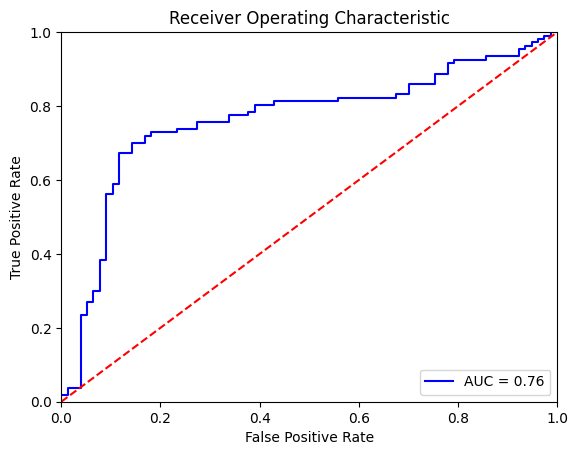

In [15]:
from transformers import BertForSequenceClassification
from transformers import DataCollatorWithPadding
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import sklearn.metrics as metrics

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('cuda')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Epoch,Training Loss,Validation Loss,Roc Auc
1,0.425300,0.405154,0.890885
2,0.452500,0.393547,0.921957
3,0.388200,0.393439,0.924020
4,0.372900,0.390053,0.932152
5,0.376500,0.428647,0.923170
6,0.377000,0.364438,0.923170
7,0.350600,0.366013,0.924263
8,0.335600,0.369372,0.926690
9,0.335800,0.351727,0.929603
10,0.278100,0.345497,0.935186


{'eval_loss': 0.34549713134765625, 'eval_roc_auc': 0.9351863090180847, 'eval_runtime': 0.6786, 'eval_samples_per_second': 271.146, 'eval_steps_per_second': 4.421, 'epoch': 10.0}
test f1 0.8846153846153846
test precision 0.9108910891089109
test recall 0.8598130841121495
test accuracy 0.9108910891089109
test roc_auc 0.9355504308775336



train f1 0.9125000000000001
train precision 0.9147869674185464
train recall 0.9102244389027432
train accuracy 0.9046321525885559
train roc_auc 0.9541910988295028


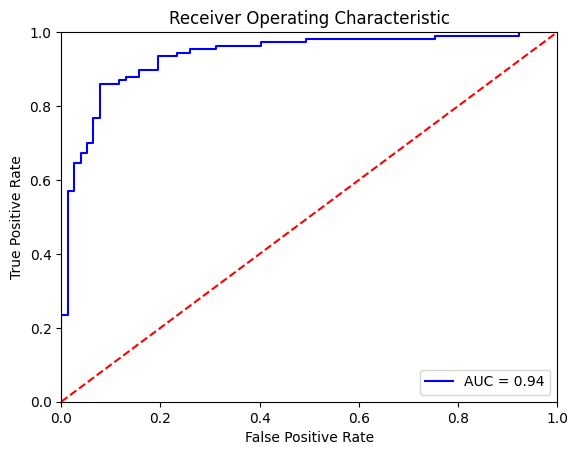

In [17]:
for param in model.bert.parameters():
    param.requires_grad = True

model.dropout.p = 0.0

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.0001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()